# P2-Lab1: Converting Raw Text into Sequence Data

We are going to load raw text, convert into tokens and indexed sequences, and perform some statistical analysis.

In [375]:
import collections
import os
import re
import urllib

import matplotlib.pyplot as plt
import numpy as np
import torch

## The Dataset

We will work with H. G. Wells'
[The Time Machine](http://www.gutenberg.org/ebooks/35),
a book containing just over 30,000 words.
The following `_download` method
reads the raw text into a string.

In [376]:
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

def download(url: str, folder: str = './') -> str:
    """Download a file to a specified folder."""
    os.makedirs(folder, exist_ok=True)
    fname = os.path.join(folder, url.split('/')[-1])
    
    if not os.path.exists(fname):
        print(f'Downloading {fname} from {url}...')
        urllib.request.urlretrieve(url, fname)
    
    return fname


class TimeMachine:
    """The Time Machine dataset."""
    
    def _download(self) -> str:
        fname = download(DATA_URL + 'timemachine.txt', './')
        with open(fname) as f:
            return f.read()
    
    def _preprocess(self, text: str) -> str:
        return re.sub('[^A-Za-z]+', ' ', text).lower()
    
    def _tokenize(self, text: str) -> list[str]:
        return list(text)
    
    def build(self, raw_text: str, vocab: 'Vocab | None' = None) -> tuple[list[int], 'Vocab']:
        tokens = self._tokenize(self._preprocess(raw_text))
        if vocab is None:
            vocab = Vocab(tokens)
        corpus = [vocab[token] for token in tokens]
        return corpus, vocab

We download the raw text and show the first 60 characters.

In [377]:
data = TimeMachine()
raw_text = data._download()
raw_text[:60]

'The Time Machine, by H. G. Wells [1898]\n\n\n\n\nI\n\n\nThe Time Tra'

For simplicity, we ignore punctuation and capitalization when preprocessing the raw text.

We show the first 60 characters preprocessed.

In [378]:
text = data._preprocess(raw_text)
text[:60]

'the time machine by h g wells i the time traveller for so it'

## Tokenization

*Tokens* are the atomic (indivisible) units of text.
Each time step corresponds to 1 token,
but what precisely constitutes a token is a **design** choice.

Below, we tokenize our preprocessed text
into a sequence of **characters**.

In [379]:
tokens = data._tokenize(text)
','.join(tokens[:30])

't,h,e, ,t,i,m,e, ,m,a,c,h,i,n,e, ,b,y, ,h, ,g, ,w,e,l,l,s, '

## Vocabulary

These tokens are still strings.
However, the inputs to our models must consist of numerical inputs.
First, we determine the set of unique tokens in our training *corpus*.
We then assign a numerical index to each unique token.
Rare vocabulary elements are often dropped for convenience.
Whenever we encounter a token that had not been previously seen,
we represent it by a special "<unk>" token,
signifying that this is an *unknown* value.

In [380]:
class Vocab:
    """Vocabulary for text."""
    
    def __init__(
        self,
        tokens: list[str] | list[list[str]] = [],
        min_freq: int = 0,
        reserved_tokens: list[str] = []
    ):
        # Flatten a 2D list if needed
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        # The list of unique tokens
        self.idx_to_token = list(sorted(set(
            ['<unk>'] + reserved_tokens + 
            [token for token, freq in self.token_freqs if freq >= min_freq]
        )))
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self) -> int:
        return len(self.idx_to_token)

    def __getitem__(self, tokens: str | list[str] | tuple[str, ...]) -> int | list[int]:
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices: int | list[int] | torch.Tensor) -> str | list[str]:
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self) -> int:
        """Index for the unknown token."""
        return self.token_to_idx['<unk>']

We now construct a vocabulary for our dataset,
converting the sequence of strings
into a list of numerical indices.
Note that we have not lost any information
and can easily convert our dataset
back to its original (string) representation.

In [381]:
vocab = Vocab(tokens)
indices = vocab[tokens[:15]]
print('indices:', indices)
print('words:', vocab.to_tokens(indices))

indices: [21, 9, 6, 0, 21, 10, 14, 6, 0, 14, 2, 4, 9, 10, 15]
words: ['t', 'h', 'e', ' ', 't', 'i', 'm', 'e', ' ', 'm', 'a', 'c', 'h', 'i', 'n']


## Putting It All Together

Using the above classes and methods,
we **package everything into the following
`build` method of the `TimeMachine` class**,
which returns `corpus`, a list of token indices, and `vocab`,
the vocabulary of *The Time Machine* corpus.
The modifications we did here are:
(i) we tokenize text into characters, not words,
to simplify the training in later sections;
(ii) `corpus` is a single list, not a list of token lists,
since each text line in *The Time Machine* dataset
is not necessarily a sentence or paragraph.

In [382]:
corpus, vocab_char = data.build(raw_text)
print(len(corpus), len(vocab_char))
print(vocab_char.token_to_idx)

173428 28
{' ': 0, '<unk>': 1, 'a': 2, 'b': 3, 'c': 4, 'd': 5, 'e': 6, 'f': 7, 'g': 8, 'h': 9, 'i': 10, 'j': 11, 'k': 12, 'l': 13, 'm': 14, 'n': 15, 'o': 16, 'p': 17, 'q': 18, 'r': 19, 's': 20, 't': 21, 'u': 22, 'v': 23, 'w': 24, 'x': 25, 'y': 26, 'z': 27}


## Exploratory Language Statistics

Using the real corpus and the `Vocab` class defined over words,
we can inspect basic statistics concerning word use in our corpus.
Below, we construct a vocabulary from words used in *The Time Machine*
and print the ten most frequently occurring of them.

In [383]:
words = text.split()
vocab = Vocab(words)
vocab.token_freqs[:10]

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

Note that (**the ten most frequent words**)
are not all that descriptive.
Articles like "the" and "a",
pronouns like "i" and "my",
and prepositions like "of", "to", and "in"
occur often because they serve common syntactic roles.
Such words that are common but not particularly descriptive
are often called (***stop words***) and,
in previous generations of text classifiers
based on so-called bag-of-words representations,
they were most often filtered out.
However, they carry meaning and
it is not necessary to filter them out
when working with modern RNN- and
Transformer-based neural models.
If you look further down the list,
you will notice
that word frequency decays quickly.
The $10^{\textrm{th}}$ most frequent word
is less than $1/5$ as common as the most popular.
Word frequency tends to follow a power law distribution
(Zipf Law) as we go down the ranks.
To get a better idea, we **plot the figure of the word frequency**.

In [384]:
def plot(
    data: list | list[list],
    xlabel: str = '',
    ylabel: str = '',
    xscale: str = 'linear',
    yscale: str = 'linear',
    legend: list[str] | None = None,
    figsize: tuple[float, float] = (6, 4)
) -> None:
    """Plot data using matplotlib."""
    plt.figure(figsize=figsize)
    
    if not isinstance(data[0], (list, np.ndarray)):
        data = [data]
    
    for i, d in enumerate(data):
        x = np.arange(1, len(d) + 1)
        label = legend[i] if legend else None
        plt.plot(x, d, label=label)
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xscale(xscale)
    plt.yscale(yscale)
    
    if legend:
        plt.legend()
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

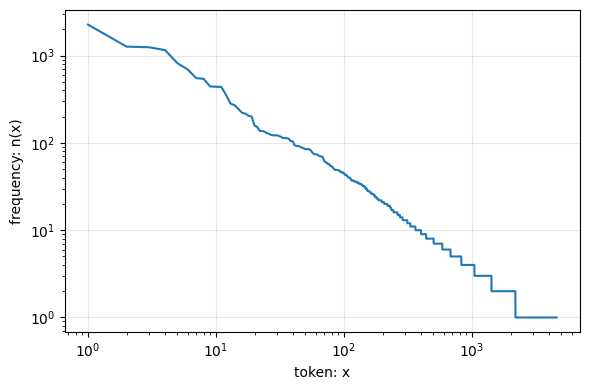

In [385]:
freqs = [freq for token, freq in vocab.token_freqs]
plot(freqs, xlabel='token: x', ylabel='frequency: n(x)',
     xscale='log', yscale='log')

After dealing with the first few words as exceptions,
all the remaining words roughly follow a straight line on a log--log plot.
This phenomenon is captured by *Zipf's law*,
which states that the frequency $n_i$
of the $i^\textrm{th}$ most frequent word is:

$$n_i \propto \frac{1}{i^\alpha},$$

which is equivalent to

$$\log n_i = -\alpha \log i + c,$$

where $\alpha$ is the exponent that characterizes
the distribution and $c$ is a constant.
This should already give us pause for thought if we want
to model words by counting statistics.
After all, we will significantly overestimate the frequency of the tail, also known as the infrequent words. But **what about the other word combinations, such as two consecutive words (bigrams), three consecutive words (trigrams)**, and beyond?
Let's see whether the bigram frequency behaves in the same manner as the single word (unigram) frequency.

In [386]:
bigram_tokens = ['--'.join(pair) for pair in zip(words[:-1], words[1:])]
bigram_vocab = Vocab(bigram_tokens)
bigram_vocab.token_freqs[:10]

[('of--the', 309),
 ('in--the', 169),
 ('i--had', 130),
 ('i--was', 112),
 ('and--the', 109),
 ('the--time', 102),
 ('it--was', 99),
 ('to--the', 85),
 ('as--i', 78),
 ('of--a', 73)]

One thing is notable here. Out of the ten most frequent word pairs, nine are composed of both stop words and only one is relevant to the actual book---"the time". Furthermore, let's see whether the trigram frequency behaves in the same manner.

In [387]:
trigram_tokens = ['--'.join(triple) for triple in zip(
    words[:-2], words[1:-1], words[2:])]
trigram_vocab = Vocab(trigram_tokens)
trigram_vocab.token_freqs[:10]

[('the--time--traveller', 59),
 ('the--time--machine', 30),
 ('the--medical--man', 24),
 ('it--seemed--to', 16),
 ('it--was--a', 15),
 ('here--and--there', 15),
 ('seemed--to--me', 14),
 ('i--did--not', 14),
 ('i--saw--the', 13),
 ('i--began--to', 13)]

Now, let's **visualize the token frequency** among these three models: unigrams, bigrams, and trigrams.

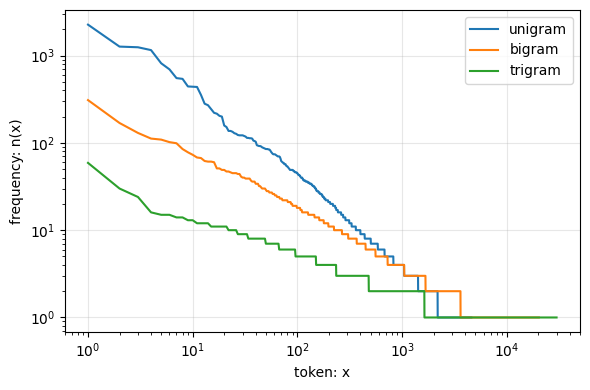

In [388]:
bigram_freqs = [freq for token, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for token, freq in trigram_vocab.token_freqs]
plot([freqs, bigram_freqs, trigram_freqs], xlabel='token: x',
     ylabel='frequency: n(x)', xscale='log', yscale='log',
     legend=['unigram', 'bigram', 'trigram'])

Beyond unigram words, sequences of words
also appear to be following Zipf's law,
albeit with a smaller exponent.
The number of distinct $n$-grams is not that large.
This gives us hope that there is quite a lot of structure in language.
Third, many $n$-grams occur very rarely.
This makes certain methods unsuitable for language modeling
and motivates the use of deep learning models.


## Summary

Text is among the most common forms of sequence data encountered in deep learning.
Common choices for what constitutes a token are characters, words, and word pieces.
To preprocess text, we usually (i) split text into tokens; (ii) build a vocabulary to map token strings to numerical indices; and (iii) convert text data into token indices for models to manipulate.
In practice, the frequency of words tends to follow Zipf's law. This is true not just for individual words (unigrams), but also for $n$-grams.

## Lab 1 Tasks

1. Execute this notebook, understanding the commands used.
2. Perform a linear fit for the exponent of Zipfian distribution for unigrams, bigrams, and trigrams in this corpus.
3. Load the spanish text "Juvenilia" found in the virtual campus and repeat the previous analysis.
4. Compare the results obtained in both cases and extract conclusions regarding the more frequent words, characters and exponents of the Zipf Law.

In [389]:
def fit_with_trimming(
    freqs: list[int],
    start: int = 10,
    min_freq: int = 2
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Fit a linear model to log-log data with trimming.
    
    Removes:
    - First `start` values (high frequency outliers)
    - Values with frequency < min_freq (removes freq=1 by default)
    """
    # Remove first high-frequency values
    freqs_trim = np.array(freqs[start:])
    
    # Remove values with frequency < min_freq (typically freq=1)
    freqs_trim = freqs_trim[freqs_trim >= min_freq]
    
    x_trim = np.arange(1, len(freqs_trim) + 1)
    
    log_freqs_trim = np.log(freqs_trim)
    coeff = np.polyfit(np.log(x_trim), log_freqs_trim, 1)
    
    return coeff, x_trim, freqs_trim

In [390]:
coeff_unigrams, x_unigrams, freqs_fit_uni = fit_with_trimming(freqs, start=10, min_freq=2)
slope_unigrams = coeff_unigrams[0]
print(f"Unigrams - Exponente α: {-slope_unigrams:.2f} (pendiente: {slope_unigrams:.2f})")

Unigrams - Exponente α: 0.97 (pendiente: -0.97)


In [391]:
coeff_bigrams, x_bigrams, freqs_fit_bi = fit_with_trimming(bigram_freqs, start=10, min_freq=2)
slope_bigrams = coeff_bigrams[0]
print(f"Bigrams - Exponente α: {-slope_bigrams:.2f} (pendiente: {slope_bigrams:.2f})")

Bigrams - Exponente α: 0.62 (pendiente: -0.62)


In [392]:
coeff_trigrams, x_trigrams, freqs_fit_tri = fit_with_trimming(trigram_freqs, start=10, min_freq=2)
slope_trigrams = coeff_trigrams[0]
print(f"Trigrams - Exponente α: {-slope_trigrams:.2f} (pendiente: {slope_trigrams:.2f})")

Trigrams - Exponente α: 0.35 (pendiente: -0.35)


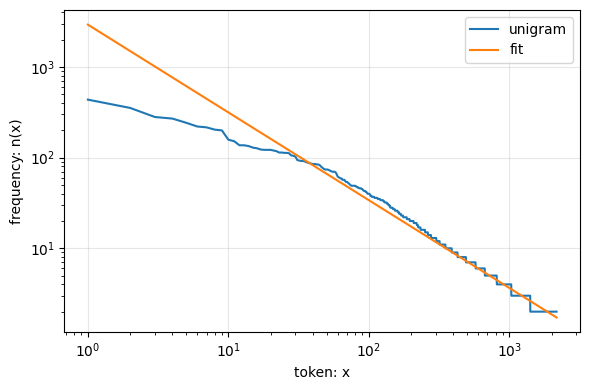

In [393]:
# Plot unigrams con fit
plt.figure(figsize=(6, 4))
plt.plot(x_unigrams, freqs_fit_uni, label='unigram')
fit_uni = np.exp(slope_unigrams * np.log(x_unigrams) + coeff_unigrams[1])
plt.plot(x_unigrams, fit_uni, label='fit')
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

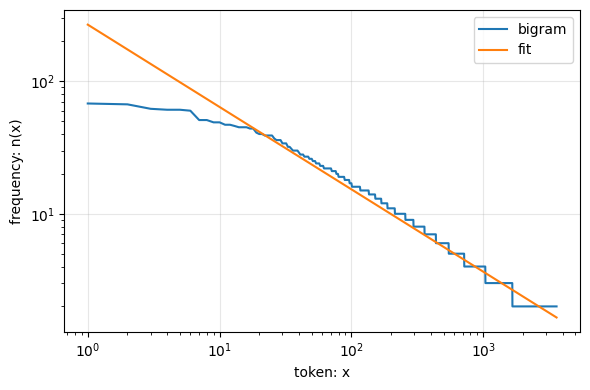

In [394]:
# Plot bigrams con fit
plt.figure(figsize=(6, 4))
plt.plot(x_bigrams, freqs_fit_bi, label='bigram')
fit_bi = np.exp(slope_bigrams * np.log(x_bigrams) + coeff_bigrams[1])
plt.plot(x_bigrams, fit_bi, label='fit')
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

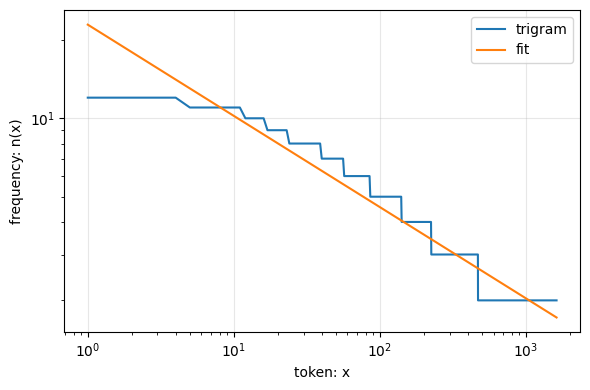

In [395]:
# Plot trigrams con fit
plt.figure(figsize=(6, 4))
plt.plot(x_trigrams, freqs_fit_tri, label='trigram')
fit_tri = np.exp(slope_trigrams * np.log(x_trigrams) + coeff_trigrams[1])
plt.plot(x_trigrams, fit_tri, label='fit')
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [396]:
def calc_r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculate R² score."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_unigrams = calc_r2(np.log(freqs_fit_uni), np.log(x_unigrams) * slope_unigrams + coeff_unigrams[1])
r2_bigrams = calc_r2(np.log(freqs_fit_bi), np.log(x_bigrams) * slope_bigrams + coeff_bigrams[1])
r2_trigrams = calc_r2(np.log(freqs_fit_tri), np.log(x_trigrams) * slope_trigrams + coeff_trigrams[1])

print(f"R² unigrams: {r2_unigrams:.4f}")
print(f"R² bigrams: {r2_bigrams:.4f}")
print(f"R² trigrams: {r2_trigrams:.4f}")

R² unigrams: 0.9815
R² bigrams: 0.9629
R² trigrams: 0.8944


## Análisis del Corpus en Español: Juvenilia

Repetimos el análisis con el texto en español "Juvenilia" de Miguel Cané,
usando el mismo preprocesamiento que para The Time Machine.

In [397]:
# Cargar texto en español
with open('./Juvenilia.txt', encoding='utf-8') as f:
    raw_text_es = f.read()

print(f"Primeros 200 caracteres:")
print(raw_text_es[:200])

Primeros 200 caracteres:


  JUVENILIA


  PROSA LIGERA




MIGUEL CANÉ


Nació en Montevideo, en 1851, durante la emigración. Estudió en el
Colegio Nacional de Buenos Aires y se graduó en Derecho en la
Universidad el año 187


In [398]:
# Preprocesar: convertir tildes a caracteres base, luego solo A-Za-z
ACCENT_MAP = str.maketrans('áéíóúüñÁÉÍÓÚÜÑ', 'aeiouunAEIOUUN')
text_es_normalized = raw_text_es.translate(ACCENT_MAP)
text_es = re.sub('[^A-Za-z]+', ' ', text_es_normalized).lower()
print(f"Primeros 200 caracteres preprocesados:")
print(text_es[:200])

Primeros 200 caracteres preprocesados:
 juvenilia prosa ligera miguel cane nacio en montevideo en durante la emigracion estudio en el colegio nacional de buenos aires y se graduo en derecho en la universidad el ano pertenecio al grupo de e


In [399]:
# Tokenización por caracteres
tokens_es = list(text_es)
vocab_char_es = Vocab(tokens_es)

print(f"Tamaño del corpus (caracteres): {len(tokens_es)}")
print(f"Tamaño del vocabulario: {len(vocab_char_es)}")
print(f"\nFrecuencias de caracteres:")
print(vocab_char_es.token_freqs)

Tamaño del corpus (caracteres): 482762
Tamaño del vocabulario: 28

Frecuencias de caracteres:
[(' ', 84270), ('e', 52059), ('a', 50835), ('o', 37423), ('s', 29038), ('n', 28564), ('i', 26889), ('r', 26407), ('l', 22825), ('d', 19167), ('u', 16867), ('c', 16642), ('t', 16447), ('m', 11580), ('p', 10135), ('b', 6602), ('v', 4380), ('g', 4296), ('q', 4002), ('h', 3956), ('y', 3319), ('f', 2917), ('z', 1749), ('j', 1712), ('x', 609), ('k', 49), ('w', 23)]


In [400]:
# Vocabulario de palabras
words_es = text_es.split()
vocab_es = Vocab(words_es)

print(f"Total palabras: {len(words_es)}")
print(f"Vocabulario único: {len(vocab_es)}")
print(f"\nLas 10 palabras más frecuentes en español:")
vocab_es.token_freqs[:10]

Total palabras: 84269
Vocabulario único: 13387

Las 10 palabras más frecuentes en español:


[('de', 5011),
 ('la', 3480),
 ('que', 2832),
 ('el', 2671),
 ('y', 2349),
 ('en', 2301),
 ('a', 1996),
 ('los', 1287),
 ('un', 1179),
 ('su', 907)]

In [401]:
# Bigramas en español
bigram_tokens_es = ['--'.join(pair) for pair in zip(words_es[:-1], words_es[1:])]
bigram_vocab_es = Vocab(bigram_tokens_es)
print("Los 10 bigramas más frecuentes:")
bigram_vocab_es.token_freqs[:10]

Los 10 bigramas más frecuentes:


[('de--la', 779),
 ('en--el', 436),
 ('en--la', 371),
 ('a--la', 306),
 ('de--los', 274),
 ('de--su', 219),
 ('de--las', 174),
 ('de--un', 174),
 ('que--se', 165),
 ('que--el', 160)]

In [402]:
# Trigramas en español
trigram_tokens_es = ['--'.join(triple) for triple in zip(words_es[:-2], words_es[1:-1], words_es[2:])]
trigram_vocab_es = Vocab(trigram_tokens_es)
print("Los 10 trigramas más frecuentes:")
trigram_vocab_es.token_freqs[:10]

Los 10 trigramas más frecuentes:


[('de--la--vida', 45),
 ('uno--de--los', 33),
 ('en--la--que', 26),
 ('en--el--fondo', 25),
 ('en--el--que', 21),
 ('a--pesar--de', 21),
 ('en--el--mundo', 19),
 ('de--su--vida', 18),
 ('dos--o--tres', 18),
 ('de--los--que', 18)]

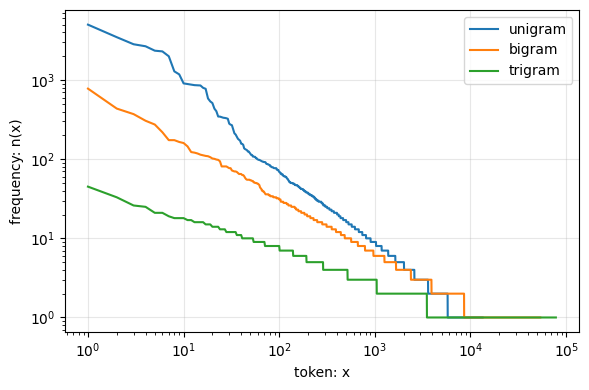

In [403]:
# Frecuencias para el gráfico
freqs_es = [freq for token, freq in vocab_es.token_freqs]
bigram_freqs_es = [freq for token, freq in bigram_vocab_es.token_freqs]
trigram_freqs_es = [freq for token, freq in trigram_vocab_es.token_freqs]

plot([freqs_es, bigram_freqs_es, trigram_freqs_es], 
     xlabel='token: x', ylabel='frequency: n(x)',
     xscale='log', yscale='log',
     legend=['unigram', 'bigram', 'trigram'])

### Ajuste de Zipf para el corpus en español

In [404]:
# Ajuste lineal para español (eliminando primeros valores y freq=1)
coeff_uni_es, x_uni_es, freqs_fit_uni_es = fit_with_trimming(freqs_es, start=10, min_freq=2)
slope_uni_es = coeff_uni_es[0]
print(f"Unigrams ES - Exponente α: {-slope_uni_es:.2f} (pendiente: {slope_uni_es:.2f})")

coeff_bi_es, x_bi_es, freqs_fit_bi_es = fit_with_trimming(bigram_freqs_es, start=10, min_freq=2)
slope_bi_es = coeff_bi_es[0]
print(f"Bigrams ES - Exponente α: {-slope_bi_es:.2f} (pendiente: {slope_bi_es:.2f})")

coeff_tri_es, x_tri_es, freqs_fit_tri_es = fit_with_trimming(trigram_freqs_es, start=10, min_freq=2)
slope_tri_es = coeff_tri_es[0]
print(f"Trigrams ES - Exponente α: {-slope_tri_es:.2f} (pendiente: {slope_tri_es:.2f})")

Unigrams ES - Exponente α: 0.90 (pendiente: -0.90)
Bigrams ES - Exponente α: 0.62 (pendiente: -0.62)
Trigrams ES - Exponente α: 0.36 (pendiente: -0.36)


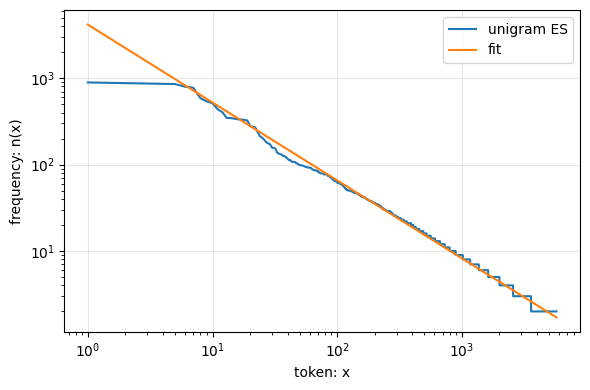

In [405]:
# Plot unigrams ES con fit
plt.figure(figsize=(6, 4))
plt.plot(x_uni_es, freqs_fit_uni_es, label='unigram ES')
fit_uni_es = np.exp(slope_uni_es * np.log(x_uni_es) + coeff_uni_es[1])
plt.plot(x_uni_es, fit_uni_es, label='fit')
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

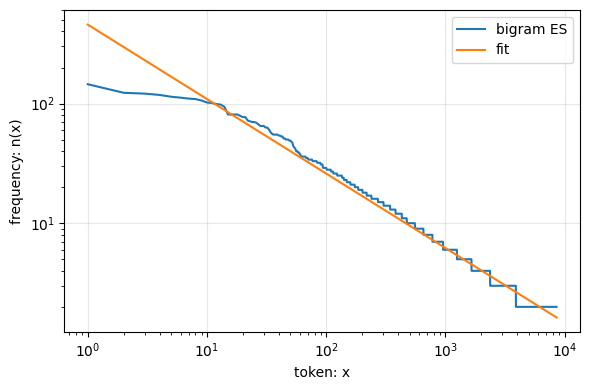

In [406]:
# Plot bigrams ES con fit
plt.figure(figsize=(6, 4))
plt.plot(x_bi_es, freqs_fit_bi_es, label='bigram ES')
fit_bi_es = np.exp(slope_bi_es * np.log(x_bi_es) + coeff_bi_es[1])
plt.plot(x_bi_es, fit_bi_es, label='fit')
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

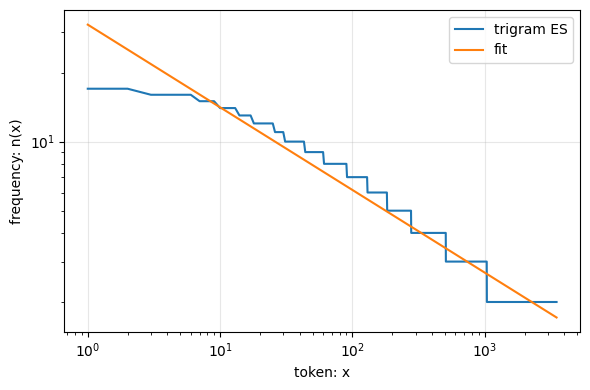

In [407]:
# Plot trigrams ES con fit
plt.figure(figsize=(6, 4))
plt.plot(x_tri_es, freqs_fit_tri_es, label='trigram ES')
fit_tri_es = np.exp(slope_tri_es * np.log(x_tri_es) + coeff_tri_es[1])
plt.plot(x_tri_es, fit_tri_es, label='fit')
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [408]:
# R² para español
r2_uni_es = calc_r2(np.log(freqs_fit_uni_es), np.log(x_uni_es) * slope_uni_es + coeff_uni_es[1])
r2_bi_es = calc_r2(np.log(freqs_fit_bi_es), np.log(x_bi_es) * slope_bi_es + coeff_bi_es[1])
r2_tri_es = calc_r2(np.log(freqs_fit_tri_es), np.log(x_tri_es) * slope_tri_es + coeff_tri_es[1])

print(f"R² unigrams ES: {r2_uni_es:.4f}")
print(f"R² bigrams ES: {r2_bi_es:.4f}")
print(f"R² trigrams ES: {r2_tri_es:.4f}")

R² unigrams ES: 0.9878
R² bigrams ES: 0.9653
R² trigrams ES: 0.9044


## Comparación y Conclusiones

In [409]:
print("=" * 70)
print("RESUMEN COMPARATIVO: INGLÉS vs ESPAÑOL")
print("=" * 70)

print(f"\n{'Métrica':<25} {'Inglés':>20} {'Español':>20}")
print("-" * 70)

print(f"\n--- Exponentes de Zipf (α) ---")
print(f"{'Unigrams α':<25} {-slope_unigrams:>20.2f} {-slope_uni_es:>20.2f}")
print(f"{'Bigrams α':<25} {-slope_bigrams:>20.2f} {-slope_bi_es:>20.2f}")
print(f"{'Trigrams α':<25} {-slope_trigrams:>20.2f} {-slope_tri_es:>20.2f}")

print(f"\n--- Coeficientes R² ---")
print(f"{'R² Unigrams':<25} {r2_unigrams:>20.4f} {r2_uni_es:>20.4f}")
print(f"{'R² Bigrams':<25} {r2_bigrams:>20.4f} {r2_bi_es:>20.4f}")
print(f"{'R² Trigrams':<25} {r2_trigrams:>20.4f} {r2_tri_es:>20.4f}")

print(f"\n--- Tamaño del corpus ---")
print(f"{'Total palabras':<25} {len(words):>20} {len(words_es):>20}")
print(f"{'Vocabulario único':<25} {len(vocab):>20} {len(vocab_es):>20}")

RESUMEN COMPARATIVO: INGLÉS vs ESPAÑOL

Métrica                                 Inglés              Español
----------------------------------------------------------------------

--- Exponentes de Zipf (α) ---
Unigrams α                                0.97                 0.90
Bigrams α                                 0.62                 0.62
Trigrams α                                0.35                 0.36

--- Coeficientes R² ---
R² Unigrams                             0.9815               0.9878
R² Bigrams                              0.9629               0.9653
R² Trigrams                             0.8944               0.9044

--- Tamaño del corpus ---
Total palabras                           32775                84269
Vocabulario único                         4580                13387


In [410]:
print("\n" + "=" * 70)
print("10 CARACTERES MÁS FRECUENTES")
print("=" * 70)
print(f"\n{'Inglés':<35} {'Español':<35}")
print("-" * 70)
for i in range(10):
    en_char, en_freq = vocab_char.token_freqs[i]
    es_char, es_freq = vocab_char_es.token_freqs[i]
    en_str = f"'{en_char}': {en_freq}"
    es_str = f"'{es_char}': {es_freq}"
    print(f"{en_str:<35} {es_str:<35}")


10 CARACTERES MÁS FRECUENTES

Inglés                              Español                            
----------------------------------------------------------------------
' ': 32775                          ' ': 84270                         
'e': 17838                          'e': 52059                         
't': 13515                          'a': 50835                         
'a': 11704                          'o': 37423                         
'i': 10138                          's': 29038                         
'n': 9917                           'n': 28564                         
'o': 9758                           'i': 26889                         
's': 8486                           'r': 26407                         
'h': 8257                           'l': 22825                         
'r': 7674                           'd': 19167                         


In [411]:
print("\n" + "=" * 70)
print("10 PALABRAS MÁS FRECUENTES")
print("=" * 70)
print(f"\n{'Inglés':<35} {'Español':<35}")
print("-" * 70)
for i in range(10):
    en_word, en_freq = vocab.token_freqs[i]
    es_word, es_freq = vocab_es.token_freqs[i]
    en_str = f"{en_word}: {en_freq}"
    es_str = f"{es_word}: {es_freq}"
    print(f"{en_str:<35} {es_str:<35}")


10 PALABRAS MÁS FRECUENTES

Inglés                              Español                            
----------------------------------------------------------------------
the: 2261                           de: 5011                           
i: 1267                             la: 3480                           
and: 1245                           que: 2832                          
of: 1155                            el: 2671                           
a: 816                              y: 2349                            
to: 695                             en: 2301                           
was: 552                            a: 1996                            
in: 541                             los: 1287                          
that: 443                           un: 1179                           
my: 440                             su: 907                            


In [412]:
print("\n" + "=" * 70)
print("10 BIGRAMAS MÁS FRECUENTES")
print("=" * 70)
print(f"\n{'Inglés':<35} {'Español':<35}")
print("-" * 70)
for i in range(10):
    en_bi, en_freq = bigram_vocab.token_freqs[i]
    es_bi, es_freq = bigram_vocab_es.token_freqs[i]
    en_str = f"{en_bi}: {en_freq}"
    es_str = f"{es_bi}: {es_freq}"
    print(f"{en_str:<35} {es_str:<35}")


10 BIGRAMAS MÁS FRECUENTES

Inglés                              Español                            
----------------------------------------------------------------------
of--the: 309                        de--la: 779                        
in--the: 169                        en--el: 436                        
i--had: 130                         en--la: 371                        
i--was: 112                         a--la: 306                         
and--the: 109                       de--los: 274                       
the--time: 102                      de--su: 219                        
it--was: 99                         de--las: 174                       
to--the: 85                         de--un: 174                        
as--i: 78                           que--se: 165                       
of--a: 73                           que--el: 160                       


In [415]:
print("\n" + "=" * 70)
print("10 TRIGRAMAS MÁS FRECUENTES")
print("=" * 70)
print(f"\n{'Inglés':<35} {'Español':<35}")
print("-" * 70)
for i in range(10):
    en_tri, en_freq = trigram_vocab.token_freqs[i]
    es_tri, es_freq = trigram_vocab_es.token_freqs[i]
    en_str = f"{en_tri}: {en_freq}"
    es_str = f"{es_tri}: {es_freq}"
    print(f"{en_str:<35} {es_str:<35}")


10 TRIGRAMAS MÁS FRECUENTES

Inglés                              Español                            
----------------------------------------------------------------------
the--time--traveller: 59            de--la--vida: 45                   
the--time--machine: 30              uno--de--los: 33                   
the--medical--man: 24               en--la--que: 26                    
it--seemed--to: 16                  en--el--fondo: 25                  
it--was--a: 15                      en--el--que: 21                    
here--and--there: 15                a--pesar--de: 21                   
seemed--to--me: 14                  en--el--mundo: 19                  
i--did--not: 14                     de--su--vida: 18                   
i--saw--the: 13                     dos--o--tres: 18                   
i--began--to: 13                    de--los--que: 18                   


### Conclusiones

A pesar de ser un corpus limitado (un único libro), podemos sacar conclusiones interesantes de él.

En primer lugar, vemos que la Ley de Zipf se cumple claramente para los unigramas, teniendo en ambos idiomas un R² mayor a 0.98, lo cual indica que al representar la frecuencia de los tokens vemos una relación lineal entre el logaritmo de la frecuencia y el logaritmo del orden del token. Para los bigramas y trigramas, también se cumple, obteniendo un R² ~0.96 y ~0.90 respectivamente en ambos idiomas. Aunque no es un resultado tan bueno como para los unigramas, esto es esperable ya que estamos usando un corpus limitado. Aún así, podemos seguir viendo que hay una dependencia lineal clara y estos valores de R² siguen siendo considerados buenos para validar el comportamiento de la ley de Zipf.

Los exponentes α que obtenemos son consistentes con los valores típicos para lenguaje natural, que suelen estar entre 1.0 y 1.3. En ambos idiomas vemos coeficientes de Zipf prácticamente idénticos para bigramas y trigramas, aunque para los unigramas es mayor en inglés que en español (0.97 vs 0.90). Eso quiere decir que en español la distribución es más horizontal, hay menos diferencia entre las frecuencias de tokens.

Un apunte interesante es que en el español, el mismo documento tiene 2.5 veces más palabras y casi 3 veces más palabras únicas que en inglés. Esto implica por una parte que el español es un idioma más rico gramaticalmente, pero por otra que resulta menos eficiente en términos de información expresada por palabra. Como la velocidad de lectura es similar en ambos idiomas, esto significa que el texto en español requiere significativamente más tiempo para ser leído. Mientras que en lenguaje hablado el español compensa su menor densidad informacional hablando más rápido, esta compensación no ocurre en el lenguaje escrito.

Esto también se ve reflejado en los bigramas, donde en inglés entre los más frecuentes encontramos algunos que contienen sustantivos relevantes como "the--time", mientras que en español los primeros 10 están dominados casi exclusivamente por palabras funcionales. También es curioso que los dos trigramas más frecuentes en inglés ("the--time--traveller": 59 y "the--time--machine": 30) no aparecen entre los 10 primeros en español. Esto quiere decir que cuando en 59 ocasiones en inglés se refiere al protagonista con un único trigrama fijo, en español nos referimos a él de formas muy distintas, usando mayor variabilidad referencial. Esto se debe tanto a la flexibilidad sintáctica del español (orden de palabras más libre) como a diferentes estrategias discursivas: donde el inglés repite sintagmas nominales fijos para mantener coherencia, el español tiende a mayor variación léxica.